In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

In [2]:
import json
from pathlib import Path


def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


def save_json(path, payload):
    ensure_dir(Path(path).parent)
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)

In [9]:
def load_data(n=5000, random_state=42):
    rng = np.random.default_rng(random_state)

    df = pd.DataFrame({
        "tenure_months": rng.integers(1, 72, n),
        "monthly_charges": rng.normal(70, 30, n).clip(20, 150),
        "contract_type": rng.choice(
            ["month-to-month", "one-year", "two-year"], n
        ),
        "internet_service": rng.choice(
            ["dsl", "fiber", "none"], n
        ),
        "payment_method": rng.choice(
            ["credit_card", "bank_transfer", "electronic_check"], n
        ),
    })

    churn_prob = (
        (df["contract_type"] == "month-to-month").astype(int) * 0.35
        + (df["monthly_charges"] > 90).astype(int) * 0.25
        + (df["tenure_months"] < 12).astype(int) * 0.3
    )

    df["churn"] = (
        rng.random(n) < churn_prob.clip(0, 0.9)
    ).astype(int)

    return df

In [11]:
import numpy as np
import pandas as pd
df = load_data()

print(df.head())
print("\nShape:", df.shape)
print("\nChurn Rate:")
print(df["churn"].value_counts(normalize=True))

   tenure_months  monthly_charges contract_type internet_service  \
0              7        58.716874      two-year            fiber   
1             55        56.257546      two-year            fiber   
2             47        93.068976      one-year            fiber   
3             32        94.573125      one-year             none   
4             31        53.947385      one-year              dsl   

     payment_method  churn  
0  electronic_check      0  
1  electronic_check      0  
2  electronic_check      0  
3     bank_transfer      0  
4       credit_card      0  

Shape: (5000, 6)

Churn Rate:
churn
0    0.7766
1    0.2234
Name: proportion, dtype: float64


In [17]:
X = df.drop(columns="churn")
y = df["churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5000, 5)
y shape: (5000,)


In [18]:
num_features = ["tenure_months", "monthly_charges"]
cat_features = ["contract_type", "internet_service", "payment_method"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

In [19]:
logreg_model = LogisticRegression(max_iter=1000)

logreg_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", logreg_model),
])

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [21]:
logreg_pipeline.fit(X_train, y_train)

logreg_preds = logreg_pipeline.predict(X_test)

logreg_f1 = f1_score(y_test, logreg_preds)

print("Logistic Regression F1:", logreg_f1)

Logistic Regression F1: 0.4098360655737705


In [22]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", rf_model),
])

rf_pipeline.fit(X_train, y_train)

rf_preds = rf_pipeline.predict(X_test)

rf_f1 = f1_score(y_test, rf_preds)

print("Random Forest F1:", rf_f1)

Random Forest F1: 0.4688279301745636


In [23]:
ensure_dir("models")

joblib.dump(logreg_pipeline, "models/logreg_model.joblib")
joblib.dump(rf_pipeline, "models/rf_model.joblib")

joblib.dump(
    {"X_test": X_test, "y_test": y_test},
    "models/test_split.joblib"
)

print("Models saved.")

Models saved.


In [25]:
r = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

In [26]:
# Use ORIGINAL feature names (before encoding)
feature_names = X_test.columns

importance = pd.Series(
    r.importances_mean,
    index=feature_names
).sort_values(ascending=False)

importance.head(10)

contract_type       0.166280
tenure_months       0.087333
monthly_charges     0.049700
internet_service    0.026650
payment_method      0.020922
dtype: float64

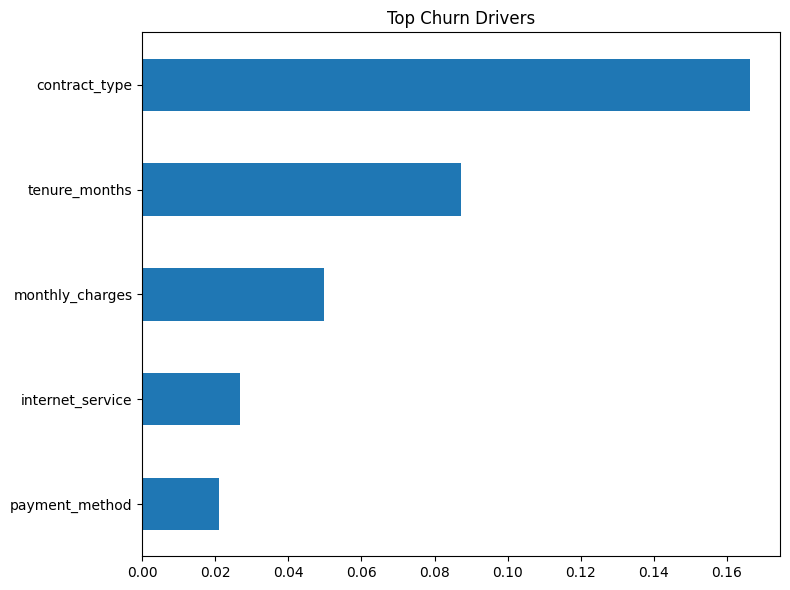

In [27]:
ensure_dir("reports/figures")

plt.figure(figsize=(8,6))

importance.head(10).plot(
    kind="barh",
    title="Top Churn Drivers"
)

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "reports/figures/churn_drivers.png",
    dpi=150
)

plt.show()

In [28]:
ensure_dir("reports")

# Save metrics
save_json(
    "reports/metrics.json",
    {
        "logreg_f1": float(logreg_f1),
        "rf_f1": float(rf_f1)
    }
)

# Save top drivers
importance.head(10).to_csv(
    "reports/top_churn_drivers.csv"
)

print("Reports saved.")

Reports saved.


In [29]:
import os

for root, dirs, files in os.walk("reports"):
    for file in files:
        print(os.path.join(root, file))

reports/top_churn_drivers.csv
reports/metrics.json
reports/figures/churn_drivers.png


In [30]:
import json

with open("reports/metrics.json") as f:
    metrics = json.load(f)

metrics

{'logreg_f1': 0.4098360655737705, 'rf_f1': 0.4688279301745636}

In [31]:
print("=== BUSINESS INSIGHTS ===\n")

print("1. Customers on month-to-month contracts churn the most.")
print("2. High monthly charges increase churn risk.")
print("3. New customers (low tenure) are unstable.\n")

print("RECOMMENDATIONS:")
print("- Offer discounts for long-term contracts.")
print("- Provide loyalty benefits to new users.")
print("- Review pricing strategy.")

=== BUSINESS INSIGHTS ===

1. Customers on month-to-month contracts churn the most.
2. High monthly charges increase churn risk.
3. New customers (low tenure) are unstable.

RECOMMENDATIONS:
- Offer discounts for long-term contracts.
- Provide loyalty benefits to new users.
- Review pricing strategy.
